# imports and data cleaning

In [61]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from statsmodels.stats.power import TTestPower

In [62]:
# import datasets
df = pd.read_csv("../dataset/global_gdp_inflation_2000_2024.csv")
df

,Year,Country,ISO3,GDP_Growth_Percent,Inflation_Percent,Data_Type,Source
0,2001,Afghanistan,AFG,-9.431974,NaN,Historical,World Bank API
1,2002,Afghanistan,AFG,28.600001,NaN,Historical,World Bank API
2,2003,Afghanistan,AFG,8.832278,NaN,Historical,World Bank API
3,2004,Afghanistan,AFG,1.414118,NaN,Historical,World Bank API
4,2005,Afghanistan,AFG,11.229715,12.686269,Historical,World Bank API
...,...,...,...,...,...,...,...
5199,2020,Zimbabwe,ZWE,-7.816951,557.201817,Historical,World Bank API
5200,2021,Zimbabwe,ZWE,8.468017,98.546105,Historical,World Bank API
5201,2022,Zimbabwe,ZWE,6.139263,104.705171,Historical,World Bank API
5202,2023,Zimbabwe,ZWE,5.350869,NaN,Historical,World Bank API


In [63]:
# creating new data for philippines and indonesia gdp growth
df = df[df["Country"].isin(["Philippines", "United States"])]
df = df.pivot(index="Year", columns="Country", values="GDP_Growth_Percent").reset_index()
df = df.sort_values("Year").reset_index(drop=True)
df

Country,Year,Philippines,United States
0,2000,4.382505,4.077586
1,2001,3.049231,0.955538
2,2002,3.716255,1.700447
3,2003,5.086911,2.795606
4,2004,6.569229,3.847772
5,2005,4.942505,3.483550
6,2006,5.316417,2.784540
7,2007,6.519292,2.003858
8,2008,4.344487,0.113587
9,2009,1.448323,-2.576500


In [64]:
# create .csv file for the new data
df.to_csv("../dataset/philippines_indonesia_gdp_growth.csv", index=False)

In [65]:
# open the new .csv file
df = pd.read_csv("../dataset/philippines_indonesia_gdp_growth.csv", delimiter=",")
df.set_index('Year', inplace=True)
print(df)

      Philippines  United States
Year                            
2000     4.382505       4.077586
2001     3.049231       0.955538
2002     3.716255       1.700447
2003     5.086911       2.795606
2004     6.569229       3.847772
2005     4.942505       3.483550
2006     5.316417       2.784540
2007     6.519292       2.003858
2008     4.344487       0.113587
2009     1.448323      -2.576500
2010     7.334500       2.695193
2011     3.858233       1.564407
2012     6.896952       2.289113
2013     6.750531       2.117830
2014     6.347987       2.523820
2015     6.348310       2.945550
2016     7.149457       1.819451
2017     6.930988       2.457622
2018     6.341486       2.966505
2019     6.118526       2.583825
2020    -9.518295      -2.163029
2021     5.714733       6.055053
2022     7.580982       2.512375
2023     5.518950       2.887556
2024     5.692016       2.793001


In [66]:
# summary of 2 selected countries
df.describe()

,Philippines,United States
count,25.000000,25.000000
mean,4.977620,2.209370
std,3.359690,1.763957
min,-9.518295,-2.576500
25%,4.382505,1.819451
50%,5.714733,2.523820
75%,6.569229,2.887556
max,7.580982,6.055053


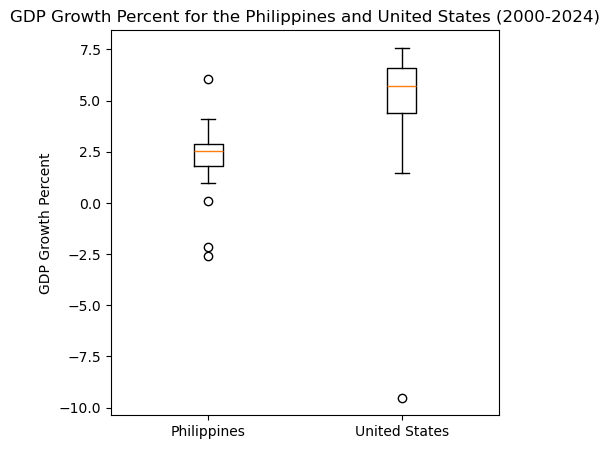

In [67]:
# check for outliers
plt.figure(figsize=(5,5))
plt.boxplot(df[['United States','Philippines']],
            tick_labels=df.columns)
plt.title('GDP Growth Percent for the Philippines and United States (2000-2024)')
plt.ylabel('GDP Growth Percent')
#plt.xticks(rotation=45)
plt.show()

In [68]:
# removing 3-sigma outliers
z_nuclear = stats.zscore(df['United States'])
nuc_outliers = (z_nuclear<-3)|(z_nuclear>3)
df = df[~nuc_outliers]

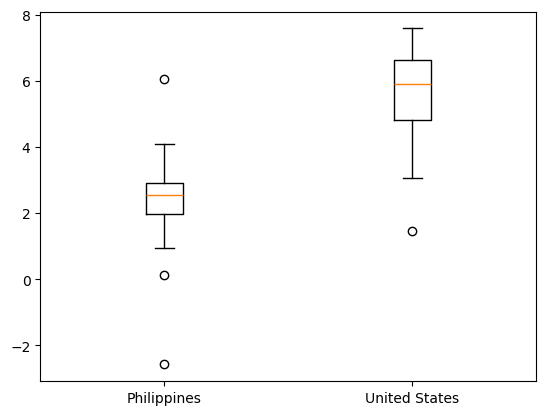

In [69]:
# wind
# removing 3-sigma outliers
z_wind = stats.zscore(df['Philippines'])
wind_outliers = (z_wind<-3)|(z_wind>3)
df = df[~wind_outliers]
plt.boxplot(df[['United States','Philippines']],tick_labels=df.columns)
plt.show()

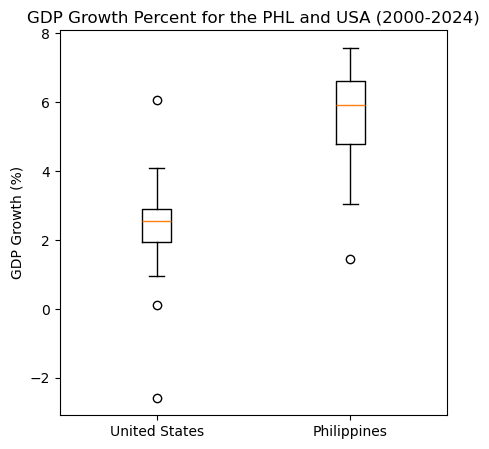

In [70]:
# check for outliers
plt.figure(figsize=(5,5))
plt.boxplot(df[['United States','Philippines']],tick_labels=['United States','Philippines'])
plt.title("GDP Growth Percent for the PHL and USA (2000-2024)")
plt.ylabel('GDP Growth (%)')
plt.show()

# United States Vs Philippines

In [71]:
# shapiro-wilk normality test
USAw_stat, USAp_value = stats.shapiro(df['United States'])
print("United States:")
print(f"w_stat: {USAw_stat:.4f}")
print(f"P-value: {USAp_value:.4f}")

# verdict
alpha = 0.05
if USAp_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data \n")

# shapiro-wilk normality test
PHLw_stat, PHLp_value = stats.shapiro(df['Philippines'])

print("\nPhilippines:")
print(f"w_stat: {PHLw_stat:.4f}")
print(f"P-value: {PHLp_value:.4f}")

# verdict
alpha = 0.05
if PHLp_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

United States:
w_stat: 0.8672
P-value: 0.0046
Non-normal data

Philippines:
w_stat: 0.9241
P-value: 0.0719
Normal data


In [72]:
var_nuc = df['United States'].var(ddof=1)
var_coal = df['Philippines'].var(ddof=1)

# F-statistic
if var_nuc > var_coal:
    f_stat = var_nuc/var_coal
else:
    f_stat = var_coal/var_nuc

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_nuc = df['United States'].count()-1
dof_coal = df['Philippines'].count()-1

# probability value
p_value = 1 - stats.f.cdf(f_stat, dof_nuc, dof_coal)
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("unequal variances")
else:
    # fail to reject null hypothesis
    print("equal variances")

f_stat = 1.0529
p_value = 0.4514
equal variances


In [73]:
t_stat, p_value = stats.ttest_ind(df['United States'],df['Philippines'],
                                  alternative='greater',
                                  equal_var=True)

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("USA-type is better than PHL-type.")
    # fail to reject null hypothesis
else:
    print("There is no significant difference between USA-type and PHL-type.")

t_stat = -7.2532
p_value = 1.0000
There is no significant difference between USA-type and PHL-type.


In [ ]:
# cohen's d
nuc_mean = df['United States'].mean()
coal_mean = df['Philippines'].mean()
nuc_std = df['United States'].std(ddof=1)

d = abs((nuc_mean - coal_mean)/nuc_std)

print(f"Cohen's d: {d:.4f}")

# power of a test
power = TTestPower().power(
    effect_size = -d, # difference must be negative for alternative='smaller'
    nobs = df['United States'].count(),
    alpha = 0.05,
    alternative = "smaller"
)

print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 2.0674
Power of the test: 100.00%
